# POC_DDM_final — Classification Performance Comparison

Covers **16 models** (4 families × 4 SC levels) across two datasets, two preprocessing
variants, three curve types, and five metrics (accuracy, F1, AUC-ROC, sensitivity, specificity).

| Dimension | Values |
|---|---|
| Dataset | DDM_01_01, DDM_01_04 |
| Preprocessing | Original `POC_DDM_final`, NC-Subtract `POC_DDM_final_nc_subtract` |
| Curve type | Ori (raw), Moving Avg, Wavelet Sym8 |
| Family | CGD, CGD+Cos, CGD+Attn, CCGD-ST |
| SC level | SC0 (no SupCon), SC1, SC2, SC3 |


In [12]:
import os, sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              recall_score, confusion_matrix)

try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass

%load_ext autoreload
%autoreload 2
import config
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [13]:
# ── Well-level accuracy helpers ─────────────────────────────────────────────
# classification_performances.joblib stores y_trues_/y_preds_AC_* per fold (pixel-level,
# test-set order) but not which global pixel/well each entry came from. To group by well
# we reconstruct the exact same (mask -> rare-class filter -> well-stratified split) that
# evaluate_outlier_filters used -- see model_utils.build_well_stratified_random_split and
# 06_model_prediction_report.py's compute_filtered_splits (same recipe, ported here since
# 06's filename isn't directly importable).
sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')
from model_utils import build_well_stratified_random_split, build_well_stratified_nfold_splits
from sklearn.preprocessing import LabelEncoder


def load_well_ids_and_labels(exp_path):
    """y_full/well_ids_full exactly as 03_main_training.py derives them. well_ids_full
    comes from the RAW (pre label-mapping) Y_well when metadata has no well_id column --
    deliberately independent of how config.LABEL_MAPPINGS later buckets labels."""
    training_data = joblib.load(exp_path / config.TRAINING_DATA_PATH)
    Y_well = training_data["Y_well"]
    metadata_df = pd.DataFrame(training_data["metadata"])
    well_ids_full = (metadata_df["well_id"].values if "well_id" in metadata_df.columns
                      else np.array(Y_well).copy())

    label_mappings = config.get_label_mappings(exp_path)
    if exp_path.name in label_mappings:
        mapping = label_mappings[exp_path.name]
        Y_well = [mapping.get(w, w) for w in Y_well]

    y_full = LabelEncoder().fit_transform(Y_well)
    return y_full, well_ids_full


def compute_filtered_test_split(y_full, well_ids_full, n_splits=1):
    """Reconstructs the None-filter + rare-class-drop + well-stratified split
    evaluate_outlier_filters used for outlier_filter=None. Returns (global_idx_of_test,
    well_ids_of_test), in the same order as the cached y_trues_/y_preds_AC_* arrays."""
    unique_classes, class_counts = np.unique(y_full, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_full, rare)
    y_v, w_v = y_full[valid], well_ids_full[valid]
    global_idx = np.where(valid)[0]

    n_classes = len(np.unique(y_v))
    if n_splits == 1:
        test_size = max(len(y_v) * 0.10, n_classes) / len(y_v)
        _, test_idx = build_well_stratified_random_split(y_v, w_v, test_size=test_size)["random_split"]
    else:
        _, test_idx = next(iter(build_well_stratified_nfold_splits(y_v, w_v, n_splits=n_splits).values()))

    return global_idx[test_idx], w_v[test_idx]


def well_level_accuracy(y_trues_flat, preds_flat, well_ids_test):
    """Majority-votes each well's pixel predictions into one verdict; accuracy over wells.
    The true label per well should be unanimous (one well = one label) -- a mismatch
    there signals a split-reconstruction bug, not real label noise."""
    wells = np.unique(well_ids_test)
    n_true_mismatch = 0
    correct = 0
    for w in wells:
        m = well_ids_test == w
        true_vals = pd.Series(y_trues_flat[m])
        if true_vals.nunique() > 1:
            n_true_mismatch += 1
        true_label = true_vals.mode()[0]
        pred_label = pd.Series(preds_flat[m]).mode()[0]
        correct += int(true_label == pred_label)
    if n_true_mismatch:
        print(f"  [!] {n_true_mismatch} well(s) had a non-unanimous true label -- "
              f"split reconstruction likely mismatched training.")
    return correct / len(wells), len(wells)


In [27]:
# ── Model universe ────────────────────────────────────────────────────────────
# 4 families × 4 SC levels = 16 models

FAMILIES = [
            'cnn_gru_dual', 
            # 'cnn_gru_dual_cosine_recon',
            'cnn_gru_dual_attn_recon', 
            # 'ccgd_arch_poc_st'
            ]
# SC_LEVELS = [0, 1, 2, 3]
SC_LEVELS = [0]

# model key used as the joblib lookup suffix: y_preds_AC_<key>_
MODEL_KEY = {
    (fam, 0): fam for fam in FAMILIES
}
MODEL_KEY.update({
    ('cnn_gru_dual', 1):              'cnn_gru_dual_supcon',
    ('cnn_gru_dual_cosine_recon', 1): 'cnn_gru_dual_cosine_recon_supcon',
    ('cnn_gru_dual_attn_recon', 1):   'cnn_gru_dual_attn_recon_supcon',
    ('ccgd_arch_poc_st', 1):          'ccgd_arch_poc_st_sc1',
    ('cnn_gru_dual', 2):              'cnn_gru_dual_supcon2',
    ('cnn_gru_dual_cosine_recon', 2): 'cnn_gru_dual_cosine_recon_supcon2',
    ('cnn_gru_dual_attn_recon', 2):   'cnn_gru_dual_attn_recon_supcon2',
    ('ccgd_arch_poc_st', 2):          'ccgd_arch_poc_st_sc2',
    ('cnn_gru_dual', 3):              'cnn_gru_dual_supcon3',
    ('cnn_gru_dual_cosine_recon', 3): 'cnn_gru_dual_cosine_recon_supcon3',
    ('cnn_gru_dual_attn_recon', 3):   'cnn_gru_dual_attn_recon_supcon3',
    ('ccgd_arch_poc_st', 3):          'ccgd_arch_poc_st_sc3',
})

MODELS = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
MODEL_TO_FAMILY = {MODEL_KEY[(fam, sc)]: fam for sc in SC_LEVELS for fam in FAMILIES}
MODEL_TO_SC = {MODEL_KEY[(fam, sc)]: sc for sc in SC_LEVELS for fam in FAMILIES}

# ── Paths ─────────────────────────────────────────────────────────────────────
def list_folders(exp_folder):
    out = []
    for name in sorted(os.listdir(exp_folder)):
        p = os.path.join(exp_folder, name)
        if (os.path.isdir(p) and name not in config.EXCLUDED_FOLDERS
                and os.path.exists(os.path.join(p, config.TRAINING_DATA_PATH))):
            # out.append((name, p))
            out.append(name)
    return out

PREP_DIRS = {
    # 'original':    '/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final',
    'nc_subtract': '/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract',
}
CURVE_JLIB = {
    'ori':          'Ori Curves',
    'ori_norm':     'Ori Curves Norm',
    # 'avg':          'Ori Curves Avg',
    # 'avg_norm':     'Ori Curves Avg Norm',
    # 'wavelet':      'Ori Curves Wavelet Sym8',
    # 'wavelet_norm': 'Ori Curves Wavelet Sym8 Norm',
    # 'bior35':       'Ori Curves Wavelet Bior35',
    # 'bior35_norm':  'Ori Curves Wavelet Bior35 Norm',
    'sgp4':         'Ori Curves Sg P4',
    'sgp4_norm':    'Ori Curves Sg P4 Norm',
}

TARGET_FOLDERS = list_folders(PREP_DIRS['nc_subtract'])[-4:]

def short_name(folder):
    return folder.split('_U_', 1)[1]

DATASET_NAMES = [short_name(f) for f in TARGET_FOLDERS]

# ── Labels ────────────────────────────────────────────────────────────────────
FAMILY_LABELS = {
    'cnn_gru_dual':              'CNN-BiGRU',
    'cnn_gru_dual_cosine_recon': 'CNN-BiGRU + Cosine Recon',
    'cnn_gru_dual_attn_recon':   'CNN-BiGRU + Spatial Attn',
    'ccgd_arch_poc_st':          'CCGD-ST',
}
SC_LABELS   = {0: 'SC0', 1: 'SC1', 2: 'SC2', 3: 'SC3'}
PREP_LABELS = {'original': 'Original', 'nc_subtract': 'NC-Subtract'}
CURVE_LABELS = {'ori': 'Ori (raw)', 'ori_norm': 'Ori (norm)',
                'avg': 'Moving Avg', 'avg_norm': 'Moving Avg (norm)',
                'wavelet': 'Wavelet sym8', 'wavelet_norm': 'Wavelet sym8 (norm)',
                'bior35': 'Wavelet bior3.5', 'bior35_norm': 'Wavelet bior3.5 (norm)',
                'sgp4': 'SG p=4 (auto-w)', 'sgp4_norm': 'SG p=4 (norm)'}
METRIC_LABELS = {
    'accuracy':    'Accuracy',
    'f1':          'F1 macro',
    'auc':         'AUC-ROC',
    'sensitivity': 'Sensitivity',
    'specificity': 'Specificity',
}
METRICS = list(METRIC_LABELS)

# ── Colors ────────────────────────────────────────────────────────────────────
FAMILY_COLORS = {
    'cnn_gru_dual':              '#1f77b4',
    'cnn_gru_dual_cosine_recon': '#2ca02c',
    'cnn_gru_dual_attn_recon':   '#d62728',
    'ccgd_arch_poc_st':          '#9467bd',
}
SC_MARKERS = {0: 'o', 1: 's', 2: '^', 3: 'D'}
SC_LINES   = {0: '-', 1: '--', 2: ':', 3: '-.'}
PREP_COLORS  = {'original': '#4393c3', 'nc_subtract': '#d6604d'}
CURVE_COLORS = {
                'ori': '#4393c3', 'ori_norm': '#a6cee3',
                # 'avg': '#e08c00', 'avg_norm': '#f4b183',
                # 'wavelet': '#1a9850', 'wavelet_norm': '#a6d96a',
                'bior35': '#d6604d', 'bior35_norm': '#f4a582',
                # 'sgp4': '#7b2d8b', 'sgp4_norm': '#c994c7'
                }

MODEL_ROW_LABEL = {
    MODEL_KEY[(fam, sc)]: f'{SC_LABELS[sc]}  {FAMILY_LABELS[fam]}'
    for sc in SC_LEVELS for fam in FAMILIES
}

MODEL_ROW_LABEL_NO_SC = {
    MODEL_KEY[(fam, sc)]: f'{FAMILY_LABELS[fam]}'
    for sc in SC_LEVELS for fam in FAMILIES
}

print(f"{len(MODELS)} models defined.")
print("  " + "\n  ".join(MODELS))


2 models defined.
  cnn_gru_dual
  cnn_gru_dual_attn_recon


In [15]:
TARGET_FOLDERS

['D20260806_E00_C00_F4500KHz_U_DDM_01_06',
 'D20260807_E00_C00_F4500KHz_U_DDM_02_07',
 'D20260808_E00_C00_F4500KHz_U_DDM_03_01',
 'D20260810_E00_C00_F4500KHz_U_DDM_04_01']

In [16]:
def compute_metrics(perf, model_key):
    """Return dict with accuracy/f1/auc/sensitivity/specificity, or None if missing."""
    pred_k = f'y_preds_AC_{model_key}_'
    prob_k = f'y_probs_AC_{model_key}_'
    if pred_k not in perf:
        return None

    y_true  = np.concatenate(perf['y_trues_'])
    y_pred  = np.concatenate(perf[pred_k])
    y_probs = np.concatenate(perf[prob_k]) if prob_k in perf else None
    n_cls   = len(np.unique(y_true))

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)

    if y_probs is not None and n_cls > 1:
        try:
            auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    # Specificity = TN/(TN+FP) per class, macro-averaged
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    return {'accuracy': acc, 'f1': f1, 'auc': auc,
            'sensitivity': sens, 'specificity': float(np.mean(specs))}


In [17]:
def load_all():
    rows = []
    for folder in TARGET_FOLDERS:
        dataset = short_name(folder)
        for prep, base_dir in PREP_DIRS.items():
            path = Path(base_dir) / folder / 'classification_performances.joblib'
            if not path.exists():
                print(f'[WARN] missing {path}')
                continue
            data = joblib.load(path)
            for curve, jlib_key in CURVE_JLIB.items():
                perf = data.get(jlib_key, {}).get('Native', {}).get(None)
                if perf is None:
                    continue
                for model in MODELS:
                    m = compute_metrics(perf, model)
                    if m is None:
                        continue
                    rows.append(dict(dataset=dataset, preprocessing=prep,
                                     curve_type=curve, model=model,
                                     family=MODEL_TO_FAMILY[model],
                                     sc_level=MODEL_TO_SC[model], **m))
    return pd.DataFrame(rows)

df = load_all()
print(f"Loaded {len(df)} rows  |  "
      f"{df.dataset.nunique()} datasets  "
      f"{df.preprocessing.nunique()} preprocessing  "
      f"{df.curve_type.nunique()} curve types  "
      f"{df.model.nunique()} models")
df.head(4)


Loaded 20 rows  |  4 datasets  1 preprocessing  3 curve types  2 models


,dataset,preprocessing,curve_type,model,family,sc_level,accuracy,f1,auc,sensitivity,specificity
0,DDM_01_06,nc_subtract,ori,cnn_gru_dual,cnn_gru_dual,0,0.930393,0.913073,0.992633,0.912648,0.986108
1,DDM_01_06,nc_subtract,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000
2,DDM_01_06,nc_subtract,ori_norm,cnn_gru_dual,cnn_gru_dual,0,0.940209,0.924441,0.996013,0.920385,0.984448
3,DDM_01_06,nc_subtract,ori_norm,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
df

,dataset,preprocessing,curve_type,model,family,sc_level,accuracy,f1,auc,sensitivity,specificity
0,DDM_01_06,nc_subtract,ori,cnn_gru_dual,cnn_gru_dual,0,0.930393,0.913073,0.992633,0.912648,0.986108
1,DDM_01_06,nc_subtract,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000
2,DDM_01_06,nc_subtract,ori_norm,cnn_gru_dual,cnn_gru_dual,0,0.940209,0.924441,0.996013,0.920385,0.984448
3,DDM_01_06,nc_subtract,ori_norm,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000
4,DDM_01_06,nc_subtract,sgp4_norm,cnn_gru_dual,cnn_gru_dual,0,0.875187,0.837181,0.976595,0.834549,0.968748
5,DDM_02_07,nc_subtract,ori,cnn_gru_dual,cnn_gru_dual,0,0.823630,0.759254,0.955691,0.753946,0.940745
6,DDM_02_07,nc_subtract,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,0.999144,0.998643,1.000000,0.998596,0.999744
7,DDM_02_07,nc_subtract,ori_norm,cnn_gru_dual,cnn_gru_dual,0,0.911111,0.893538,0.974769,0.891088,0.954056
8,DDM_03_01,nc_subtract,ori,cnn_gru_dual,cnn_gru_dual,0,0.932192,0.937147,0.992031,0.940067,0.981332
9,DDM_03_01,nc_subtract,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
expected = len(MODELS)
check = (df.groupby(['dataset','preprocessing','curve_type'])
           .size()
           .reset_index(name='n')
           .assign(expected=expected, ok=lambda x: x.n == x.expected))
missing = check[~check.ok]
if missing.empty:
    print("All combinations fully populated.")
else:
    print("[!] Incomplete combinations:")
    display(missing)


[!] Incomplete combinations:


,dataset,preprocessing,curve_type,n,expected,ok
2,DDM_01_06,nc_subtract,sgp4_norm,1,2,False
4,DDM_02_07,nc_subtract,ori_norm,1,2,False


In [20]:
check

,dataset,preprocessing,curve_type,n,expected,ok
0,DDM_01_06,nc_subtract,ori,2,2,True
1,DDM_01_06,nc_subtract,ori_norm,2,2,True
2,DDM_01_06,nc_subtract,sgp4_norm,1,2,False
3,DDM_02_07,nc_subtract,ori,2,2,True
4,DDM_02_07,nc_subtract,ori_norm,1,2,False
5,DDM_03_01,nc_subtract,ori,2,2,True
6,DDM_03_01,nc_subtract,ori_norm,2,2,True
7,DDM_03_01,nc_subtract,sgp4_norm,2,2,True
8,DDM_04_01,nc_subtract,ori,2,2,True
9,DDM_04_01,nc_subtract,ori_norm,2,2,True


In [21]:
df.curve_type.unique()

array(['ori', 'ori_norm', 'sgp4_norm'], dtype=object)

## 1 · Summary table
Full metrics pivot for a chosen (dataset, preprocessing, curve_type).
Change the `_FILTER_*` variables to explore other slices.

In [22]:
datasets = df.dataset.unique()
CURVE_ORDER = list(CURVE_JLIB.keys())   # ['ori', 'avg', 'wavelet', 'bior35', 'sgp4']

for _FILTER_DATASET in datasets:
    print(f"===+++++++++++===")
    print(f"=== {_FILTER_DATASET} ===")
    print(f"===+++++++++++===")
    for _FILTER_PREP in df.preprocessing.unique():
        _sub = df[(df.dataset == _FILTER_DATASET) & (df.preprocessing == _FILTER_PREP)].copy()
        if _sub.empty:
            continue
        _sub['SC']     = _sub.sc_level.map(SC_LABELS)
        _sub['Family'] = _sub.family.map(FAMILY_LABELS)

        # Pivot: rows = (SC, Family), outer cols = metric, inner cols = curve_type
        _pivot = (
            _sub.set_index(['SC', 'Family', 'curve_type'])[METRICS]
            .stack()
            .rename('val')
            .reset_index()
            .pivot_table(index=['SC', 'Family'],
                        columns=['level_3', 'curve_type'],
                        values='val')
        )

        _curve_order  = [c for c in CURVE_ORDER if c in _sub.curve_type.unique()]
        _metric_order = METRICS
        _pivot = _pivot.reindex(
            columns=pd.MultiIndex.from_product([_metric_order, _curve_order])
        )
        _pivot.columns = pd.MultiIndex.from_tuples(
            [(METRIC_LABELS[m], CURVE_LABELS[c]) for m, c in _pivot.columns]
        )

        # Preserve SC / Family display order
        _sc_order  = [SC_LABELS[s]  for s in SC_LEVELS]
        _fam_order = [FAMILY_LABELS[f] for f in FAMILIES]
        _pivot = _pivot.reindex(
            pd.MultiIndex.from_product([_sc_order, _fam_order], names=['SC', 'Family'])
        )

        _pivot_pct = (_pivot * 100).round(2)

        def _col_gradient(col):
            mn, mx = col.min(), col.max()
            rng = mx - mn if mx > mn else 1e-9
            return [f'background-color: rgba(26,152,80,{0.12 + 0.72*(v - mn)/rng:.2f})'
                    for v in col]

        def _metric_borders(styler):
            for mi in range(len(_metric_order) - 1):
                last_col = (mi + 1) * len(_curve_order) - 1
                styler = styler.set_properties(
                    subset=pd.IndexSlice[:, _pivot_pct.columns[last_col]],
                    **{'border-right': '2px solid #555'}
                )
            return styler

        styled = (
            _pivot_pct.style
            .apply(_col_gradient, axis=0)
            .format("{:.2f}%")
            .set_caption(
                f"{_FILTER_DATASET}  |  {PREP_LABELS[_FILTER_PREP]}  "
                f"|  columns: metric → curve type"
            )
        )
        styled = _metric_borders(styled)
        display(styled)

===+++++++++++===
=== DDM_01_06 ===
===+++++++++++===


===+++++++++++===
=== DDM_02_07 ===
===+++++++++++===


===+++++++++++===
=== DDM_03_01 ===
===+++++++++++===


===+++++++++++===
=== DDM_04_01 ===
===+++++++++++===


In [23]:
df

,dataset,preprocessing,curve_type,model,family,sc_level,accuracy,f1,auc,sensitivity,specificity
0,DDM_01_06,nc_subtract,ori,cnn_gru_dual,cnn_gru_dual,0,0.930393,0.913073,0.992633,0.912648,0.986108
1,DDM_01_06,nc_subtract,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000
2,DDM_01_06,nc_subtract,ori_norm,cnn_gru_dual,cnn_gru_dual,0,0.940209,0.924441,0.996013,0.920385,0.984448
3,DDM_01_06,nc_subtract,ori_norm,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000
4,DDM_01_06,nc_subtract,sgp4_norm,cnn_gru_dual,cnn_gru_dual,0,0.875187,0.837181,0.976595,0.834549,0.968748
5,DDM_02_07,nc_subtract,ori,cnn_gru_dual,cnn_gru_dual,0,0.823630,0.759254,0.955691,0.753946,0.940745
6,DDM_02_07,nc_subtract,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,0.999144,0.998643,1.000000,0.998596,0.999744
7,DDM_02_07,nc_subtract,ori_norm,cnn_gru_dual,cnn_gru_dual,0,0.911111,0.893538,0.974769,0.891088,0.954056
8,DDM_03_01,nc_subtract,ori,cnn_gru_dual,cnn_gru_dual,0,0.932192,0.937147,0.992031,0.940067,0.981332
9,DDM_03_01,nc_subtract,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000


In [49]:
def plot_accuracy_by_model(df, models, prep='nc_subtract', curve='ori', figsize=(6, 4)):
    """Grouped bar chart: x=dataset, one sub-bar per model (order = `models`), y=accuracy%."""
    sub = df[(df.preprocessing == prep) & (df.curve_type == curve)]
    datasets = DATASET_NAMES
    n_models = len(models)
    bar_w = 0.8 / n_models
    x = np.arange(len(datasets))

    # dataviz-skill validated categorical palette, assigned in `models` order
    palette = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
               '#e87ba4', '#008300', '#4a3aa7', '#e34948']

    fig, ax = plt.subplots(figsize=figsize)
    for mi, model in enumerate(models):
        ys = np.array([
            (sub[(sub.dataset == ds) & (sub.model == model)]['accuracy'].iloc[0] * 100
             if not sub[(sub.dataset == ds) & (sub.model == model)].empty else np.nan)
            for ds in datasets
        ])
        offset = (mi - (n_models - 1) / 2) * bar_w
        ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
               color=palette[mi % len(palette)],
               label=MODEL_ROW_LABEL_NO_SC.get(model, model),
               edgecolor='white', linewidth=0.8)
        for xi, yi in zip(x + offset, ys):
            if not np.isnan(yi):
                ax.text(xi, yi + 0.5, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 108)
    ax.legend(fontsize=8, loc='lower right', framealpha=0.9, bbox_to_anchor=(1.5,0))
    # ax.set_title(f'Accuracy by dataset and model  |  {PREP_LABELS[prep]}  |  {CURVE_LABELS[curve]}',
                #  fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()

In [30]:
# plot_accuracy_by_model(df, ['cnn_gru_dual', 'cnn_gru_dual_supcon3', 'cnn_gru_dual_attn_recon', 'cnn_gru_dual_attn_recon_supcon3'], curve='ori')
# plot_accuracy_by_model(df, ['cnn_gru_dual', 'cnn_gru_dual_supcon3', 'cnn_gru_dual_attn_recon', 'cnn_gru_dual_attn_recon_supcon3'], curve='ori_norm')
# plot_accuracy_by_model(df, ['cnn_gru_dual', 'cnn_gru_dual_supcon3', 'cnn_gru_dual_attn_recon', 'cnn_gru_dual_attn_recon_supcon3'], curve='sgp4')
# plot_accuracy_by_model(df, ['cnn_gru_dual', 'cnn_gru_dual_supcon3', 'cnn_gru_dual_attn_recon', 'cnn_gru_dual_attn_recon_supcon3'], curve='sgp4_norm')

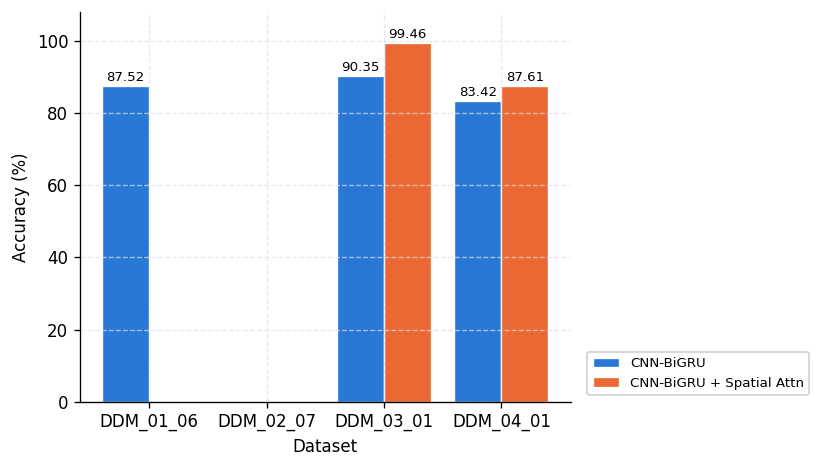

In [50]:
plot_accuracy_by_model(df, ['cnn_gru_dual', 'cnn_gru_dual_attn_recon'], curve='sgp4_norm', figsize=(8, 4))

Best so far: CGD + Cross Attn

--------
--------
--------

In [ ]:
# ── Summary: best SC / family / curve type ────────────────────────────────────
# Method: average rank across tasks (Demsar 2006) + Friedman test for significance.
# Each "task" = one (dataset × preprocessing × [other factors]) combination.
# Within each task the candidates are ranked 1=best; ties share the mean rank.
# Friedman p-value tests whether ranks are non-uniform; post-hoc: pairwise
# Wilcoxon signed-rank with Bonferroni correction.

from scipy import stats
import warnings

PRIMARY = 'accuracy'   # metric used for ranking (change to 'f1', 'auc', etc.)

def _rank_and_test(df, group_col, block_cols, metric=PRIMARY):
    """
    Returns (summary_df, friedman_p, posthoc_df).
    summary_df: group_col → mean_acc, std_acc, mean_rank, n_tasks
    friedman_p: scalar p-value (nan if <3 candidates or <2 blocks)
    posthoc_df: pairwise Wilcoxon p-values (Bonferroni-corrected), or None
    """
    keys = df[group_col].unique()
    # build one row per task = one value per candidate
    blocks = df.groupby(block_cols + [group_col])[metric].mean().reset_index()
    pivot  = blocks.pivot_table(index=block_cols, columns=group_col, values=metric)
    pivot  = pivot.dropna(how='any')   # keep only complete blocks

    # rank within each block (ascending=False → highest acc gets rank 1)
    ranked = pivot.rank(axis=1, ascending=False, method='average')

    summary = pd.DataFrame({
        'mean_acc':  pivot.mean(),
        'std_acc':   pivot.std(),
        'mean_rank': ranked.mean(),
        'n_tasks':   len(pivot),
    }).sort_values('mean_rank')

    # Friedman test
    friedman_p = float('nan')
    if pivot.shape[1] >= 3 and pivot.shape[0] >= 2:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            stat, friedman_p = stats.friedmanchisquare(*[pivot[c].values for c in pivot.columns])

    # Post-hoc pairwise Wilcoxon (Bonferroni)
    posthoc = None
    if friedman_p < 0.10 and pivot.shape[1] >= 2:
        pairs = [(a, b) for i, a in enumerate(pivot.columns) for b in list(pivot.columns)[i+1:]]
        n_pairs = len(pairs)
        rows = []
        for a, b in pairs:
            _, p = stats.wilcoxon(pivot[a].values, pivot[b].values, alternative='two-sided',
                                  zero_method='pratt')
            rows.append({'A': a, 'B': b, 'p_bonf': min(p * n_pairs, 1.0)})
        posthoc = pd.DataFrame(rows).set_index(['A', 'B'])

    return summary, friedman_p, posthoc


def _display_summary(title, summary, friedman_p, posthoc, label_map=None):
    def _label(v):
        return label_map[v] if label_map and v in label_map else str(v)

    summary = summary.copy()
    summary.index = [_label(i) for i in summary.index]

    pct = summary[['mean_acc', 'std_acc']].copy() * 100
    pct.columns = ['Mean acc (%)', 'Std (%)']
    pct['Mean rank'] = summary['mean_rank'].round(2)
    pct['N tasks']   = summary['n_tasks'].astype(int)

    friedman_str = f"Friedman p = {friedman_p:.4f}" if not pd.isna(friedman_p) else "Friedman: N/A"

    styled = (
        pct.style
        .format({'Mean acc (%)': '{:.2f}', 'Std (%)': '{:.2f}',
                 'Mean rank': '{:.2f}', 'N tasks': '{:d}'})
        .background_gradient(subset=['Mean acc (%)'], cmap='Greens')
        .background_gradient(subset=['Mean rank'],    cmap='RdYlGn_r')
        .set_caption(f"{title}  |  {friedman_str}  |  ranked by: {PRIMARY}")
    )
    display(styled)

    if posthoc is not None:
        ph = posthoc.copy()
        ph.columns = ['p (Bonf.)']
        ph_styled = ph.style.format('{:.4f}').background_gradient(cmap='RdYlGn_r')
        ph_styled = ph_styled.set_caption(f"{title} — post-hoc pairwise Wilcoxon (Bonferroni)")
        display(ph_styled)
    elif not pd.isna(friedman_p) and friedman_p >= 0.10:
        print(f"  → Friedman p = {friedman_p:.4f}: no significant difference among groups.")


print("=" * 60)
print(f"SUMMARY  (primary metric: {PRIMARY})")
print("=" * 60)

# ── 1. SC level ───────────────────────────────────────────────────────────────
print("\n── 1 · SC level ──")
summ, fp, ph = _rank_and_test(df, 'sc_level',
                               block_cols=['dataset', 'preprocessing', 'family', 'curve_type'])
_display_summary("SC level", summ, fp, ph, label_map=SC_LABELS)

# ── 2. Model family ───────────────────────────────────────────────────────────
print("\n── 2 · Model family ──")
summ, fp, ph = _rank_and_test(df, 'family',
                               block_cols=['dataset', 'preprocessing', 'sc_level', 'curve_type'])
_display_summary("Model family", summ, fp, ph, label_map=FAMILY_LABELS)

# ── 3. Curve type ─────────────────────────────────────────────────────────────
print("\n── 3 · Curve type ──")
summ, fp, ph = _rank_and_test(df, 'curve_type',
                               block_cols=['dataset', 'preprocessing', 'sc_level', 'family'])
_display_summary("Curve type", summ, fp, ph, label_map=CURVE_LABELS)


best so far:
- SC3 (not significant to 0 and 2)
- CGD + attn
- ori (but should be compared in LOFO for generalisability)

## 2 · Master heatmap — all models × all metrics
Rows = models (grouped SC0→SC3, family order within each), columns = metrics.
Each configuration is one heatmap; the function accepts any (dataset, prep, curve_type) combo.

In [ ]:
def plot_master_heatmap(df, dataset, prep, curve,
                        title_suffix='', figsize=(10, 9)):
    sub = df[(df.dataset == dataset) &
             (df.preprocessing == prep) &
             (df.curve_type == curve)]
    if sub.empty:
        print(f"No data for ({dataset}, {prep}, {curve})")
        return

    # Build row order: SC0 CGD…, SC1 CGD…, …
    row_order = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
    row_labels = [MODEL_ROW_LABEL[m] for m in row_order]
    col_labels  = [METRIC_LABELS[m] for m in METRICS]

    mat = np.full((len(row_order), len(METRICS)), np.nan)
    for ri, model in enumerate(row_order):
        row = sub[sub.model == model]
        if row.empty:
            continue
        for ci, metric in enumerate(METRICS):
            mat[ri, ci] = row[metric].iloc[0]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat, cmap='YlGn', vmin=0.5, vmax=1.0, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Score (0–1)')

    # Cell text
    for ri in range(len(row_order)):
        for ci in range(len(METRICS)):
            v = mat[ri, ci]
            if np.isnan(v):
                ax.text(ci, ri, 'N/A', ha='center', va='center',
                        fontsize=8, color='#888888')
            else:
                txt_color = 'white' if v > 0.87 else '#1a1a2e'
                ax.text(ci, ri, f'{v*100:.1f}', ha='center', va='center',
                        fontsize=8.5, fontweight='bold', color=txt_color)

    # SC-group separators (after every 4 rows)
    for sep in [4, 8, 12]:
        ax.axhline(sep - 0.5, color='#333333', linewidth=1.5)

    # SC-level left annotations
    for si, sc in enumerate(SC_LEVELS):
        mid_row = si * 4 + 1.5
        ax.text(-0.7, mid_row, SC_LABELS[sc], ha='right', va='center',
                fontsize=10, fontweight='bold', transform=ax.get_yaxis_transform())

    ax.set_xticks(range(len(METRICS)))
    ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.tick_params(left=False, bottom=False)
    ax.set_title(
        f'All models × all metrics\n'
        f'{dataset}  |  {PREP_LABELS[prep]}  |  {CURVE_LABELS[curve]}'
        + (f'  |  {title_suffix}' if title_suffix else ''),
        fontsize=11, fontweight='bold', pad=10
    )
    ax.grid(False)
    fig.tight_layout(rect=[0.08, 0, 1, 1])
    plt.show()


plot_master_heatmap(df, 'DDM_01_04', 'nc_subtract', 'ori')


### 2b · Side-by-side: Original vs NC-Subtract


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(19, 9))

def _heatmap_ax(ax, df, dataset, prep, curve):
    sub = df[(df.dataset == dataset) & (df.preprocessing == prep) & (df.curve_type == curve)]
    row_order = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
    row_labels = [MODEL_ROW_LABEL[m] for m in row_order]
    col_labels  = [METRIC_LABELS[m] for m in METRICS]
    mat = np.full((len(row_order), len(METRICS)), np.nan)
    for ri, model in enumerate(row_order):
        row = sub[sub.model == model]
        if not row.empty:
            for ci, metric in enumerate(METRICS):
                mat[ri, ci] = row[metric].iloc[0]

    im = ax.imshow(mat, cmap='YlGn', vmin=0.5, vmax=1.0, aspect='auto')
    for ri in range(len(row_order)):
        for ci in range(len(METRICS)):
            v = mat[ri, ci]
            if not np.isnan(v):
                txt_color = 'white' if v > 0.87 else '#1a1a2e'
                ax.text(ci, ri, f'{v*100:.1f}', ha='center', va='center',
                        fontsize=8, fontweight='bold', color=txt_color)
            else:
                ax.text(ci, ri, 'N/A', ha='center', va='center',
                        fontsize=8, color='#888888')
    for sep in [4, 8, 12]:
        ax.axhline(sep - 0.5, color='#333333', linewidth=1.5)
    for si, sc in enumerate(SC_LEVELS):
        ax.text(-0.75, si * 4 + 1.5, SC_LABELS[sc], ha='right', va='center',
                fontsize=9, fontweight='bold', transform=ax.get_yaxis_transform())
    ax.set_xticks(range(len(METRICS)))
    ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(row_labels, fontsize=8.5)
    ax.tick_params(left=False, bottom=False)
    ax.set_title(f'{PREP_LABELS[prep]}\n{dataset} | {CURVE_LABELS[curve]}',
                 fontsize=10, fontweight='bold')
    ax.grid(False)
    return im

_COMPARE_DATASET = 'DDM_01_04'
_COMPARE_CURVE   = 'ori'

im = _heatmap_ax(axes[0], df, _COMPARE_DATASET, 'original', _COMPARE_CURVE)
_heatmap_ax(axes[1], df, _COMPARE_DATASET, 'nc_subtract', _COMPARE_CURVE)
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label='Score (0–1)')
fig.suptitle(f'Original vs NC-Subtract  |  {_COMPARE_DATASET}  |  {CURVE_LABELS[_COMPARE_CURVE]}',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout(rect=[0.07, 0, 1, 1])
plt.show()


## 3 · SC level progression
How do metrics change from SC0 → SC1 → SC2 → SC3 for each model family?
One subplot per metric, lines = families. Fix dataset / preprocessing / curve type below.

In [ ]:
def plot_sc_progression(df, dataset, prep, curve, figsize=(14, 10)):
    sub = df[(df.dataset == dataset) &
             (df.preprocessing == prep) &
             (df.curve_type == curve)]

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    x = np.array(SC_LEVELS)

    for ai, metric in enumerate(METRICS):
        ax = axes[ai]
        for fam in FAMILIES:
            ys = []
            for sc in SC_LEVELS:
                key = MODEL_KEY[(fam, sc)]
                row = sub[sub.model == key]
                ys.append(row[metric].iloc[0] if not row.empty else np.nan)
            ys = np.array(ys) * 100  # → percentage

            ax.plot(x, ys, color=FAMILY_COLORS[fam], linewidth=1.8,
                    linestyle='-', marker='o', markersize=6,
                    label=FAMILY_LABELS[fam])
            # Annotate endpoints
            for xi, yi in zip(x, ys):
                if not np.isnan(yi):
                    ax.annotate(f'{yi:.1f}', (xi, yi),
                                textcoords='offset points', xytext=(0, 6),
                                ha='center', fontsize=7.5, color=FAMILY_COLORS[fam])

        ax.set_title(METRIC_LABELS[metric], fontsize=10, fontweight='bold')
        ax.set_xticks(SC_LEVELS)
        ax.set_xticklabels([SC_LABELS[sc] for sc in SC_LEVELS])
        ax.set_ylabel('%', fontsize=9)
        ax.set_ylim(min(50, ax.get_ylim()[0] - 2), 102)
        ax.tick_params(labelsize=8.5)

    # Legend in the 6th (empty) subplot
    axes[-1].axis('off')
    handles = [plt.Line2D([0], [0], color=FAMILY_COLORS[fam], linewidth=2,
                           marker='o', markersize=7, label=FAMILY_LABELS[fam])
               for fam in FAMILIES]
    axes[-1].legend(handles=handles, title='Model Family',
                    title_fontsize=10, fontsize=9, loc='center',
                    framealpha=0.9, edgecolor='#cccccc')

    fig.suptitle(
        f'SC Level Progression — {dataset}  |  '
        f'{PREP_LABELS[prep]}  |  {CURVE_LABELS[curve]}',
        fontsize=12, fontweight='bold', y=1.01
    )
    fig.tight_layout()
    plt.show()


plot_sc_progression(df, 'DDM_01_04', 'nc_subtract', 'ori')


### 3b · SC progression: both datasets side-by-side, one metric at a time


In [ ]:
def plot_sc_by_dataset(df, prep, curve, metric='accuracy'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    x = np.array(SC_LEVELS)

    for ax, dataset in zip(axes, DATASET_NAMES):
        sub = df[(df.dataset == dataset) &
                 (df.preprocessing == prep) &
                 (df.curve_type == curve)]
        for fam in FAMILIES:
            ys = np.array([
                (sub[sub.model == MODEL_KEY[(fam, sc)]][metric].iloc[0]
                 if not sub[sub.model == MODEL_KEY[(fam, sc)]].empty else np.nan)
                for sc in SC_LEVELS
            ]) * 100

            ax.plot(x, ys, color=FAMILY_COLORS[fam], linewidth=2,
                    marker='o', markersize=7, label=FAMILY_LABELS[fam])

        ax.set_title(dataset, fontsize=10, fontweight='bold')
        ax.set_xticks(SC_LEVELS)
        ax.set_xticklabels([SC_LABELS[sc] for sc in SC_LEVELS])
        ax.set_xlabel('SC Level')
        ax.tick_params(labelsize=9)
        if ax is axes[0]:
            ax.set_ylabel(f'{METRIC_LABELS[metric]} (%)', fontsize=10)

    handles = [plt.Line2D([0], [0], color=FAMILY_COLORS[f], linewidth=2,
                           marker='o', markersize=7, label=FAMILY_LABELS[f])
               for f in FAMILIES]
    axes[1].legend(handles=handles, fontsize=9, loc='lower right', framealpha=0.9)
    fig.suptitle(f'{METRIC_LABELS[metric]}  |  {PREP_LABELS[prep]}  |  {CURVE_LABELS[curve]}',
                 fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()

# Iterate all metrics
for _metric in METRICS:
    plot_sc_by_dataset(df, 'nc_subtract', 'ori', metric=_metric)


## 4 · Preprocessing comparison: Original vs NC-Subtract
Delta heatmap shows NC-Subtract minus Original (green = NC-Subtract wins, red = Original wins).


In [ ]:
def plot_preprocessing_delta(df, dataset, curve, metric='accuracy', figsize=(10, 7)):
    """Diverging heatmap: NC-Subtract score minus Original score."""
    row_order = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]

    orig = df[(df.dataset == dataset) & (df.preprocessing == 'original') & (df.curve_type == curve)]
    nc   = df[(df.dataset == dataset) & (df.preprocessing == 'nc_subtract') & (df.curve_type == curve)]

    deltas = []
    for model in row_order:
        o = orig[orig.model == model][metric]
        n = nc[nc.model == model][metric]
        d = (n.iloc[0] - o.iloc[0]) * 100 if not o.empty and not n.empty else np.nan
        deltas.append(d)
    deltas = np.array(deltas)

    bound = max(np.nanmax(np.abs(deltas)), 0.1)
    fig, ax = plt.subplots(figsize=figsize)
    mat = deltas[:, np.newaxis]
    im = ax.imshow(mat, cmap='RdYlGn', vmin=-bound, vmax=bound, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03,
                 label='NC-Subtract − Original (pp)')

    row_labels = [MODEL_ROW_LABEL[m] for m in row_order]
    for ri, (label, d) in enumerate(zip(row_labels, deltas)):
        txt = f'{d:+.2f} pp' if not np.isnan(d) else 'N/A'
        col = 'white' if abs(d) > bound * 0.6 else '#1a1a2e'
        ax.text(0, ri, txt, ha='center', va='center',
                fontsize=9, fontweight='bold', color=col)

    for sep in [4, 8, 12]:
        ax.axhline(sep - 0.5, color='#333333', linewidth=1.5)
    for si, sc in enumerate(SC_LEVELS):
        ax.text(-0.55, si * 4 + 1.5, SC_LABELS[sc], ha='right', va='center',
                fontsize=10, fontweight='bold', transform=ax.get_yaxis_transform())

    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_xticks([])
    ax.tick_params(left=False)
    ax.set_title(
        f'NC-Subtract effect on {METRIC_LABELS[metric]}\n'
        f'{dataset}  |  {CURVE_LABELS[curve]}  '
        f'(green = NC-Subtract better)',
        fontsize=11, fontweight='bold', pad=10
    )
    ax.grid(False)
    fig.tight_layout(rect=[0.1, 0, 1, 1])
    plt.show()


# Show delta for all metrics
for _m in METRICS:
    plot_preprocessing_delta(df, 'DDM_01_04', 'ori', metric=_m)


## 5 · Curve type comparison: Ori vs Moving Avg vs Wavelet
Bar chart per family, grouped by SC level. Pick one metric and preprocessing below.

In [ ]:
def plot_curve_comparison(df, dataset, prep, metric='accuracy', figsize=(14, 5)):
    sub = df[(df.dataset == dataset) & (df.preprocessing == prep)]
    curve_keys = list(CURVE_JLIB)   # ['ori', 'avg', 'wavelet']
    n_sc  = len(SC_LEVELS)
    n_fam = len(FAMILIES)

    # One subplot per SC level
    fig, axes = plt.subplots(1, n_sc, figsize=figsize, sharey=True)
    bar_w = 0.22
    x = np.arange(n_fam)

    for ax, sc in zip(axes, SC_LEVELS):
        for ci, curve in enumerate(curve_keys):
            ys = []
            for fam in FAMILIES:
                model = MODEL_KEY[(fam, sc)]
                row = sub[(sub.model == model) & (sub.curve_type == curve)]
                ys.append(row[metric].iloc[0] * 100 if not row.empty else np.nan)
            ys = np.array(ys)
            offset = (ci - 1) * bar_w
            bars = ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
                          color=CURVE_COLORS[curve], label=CURVE_LABELS[curve],
                          edgecolor='white', linewidth=0.8, alpha=0.9)
            for xi, yi in zip(x + offset, ys):
                if not np.isnan(yi):
                    ax.text(xi, yi + 0.2, f'{yi:.1f}', ha='center', va='bottom',
                            fontsize=7, rotation=90)

        ax.set_title(SC_LABELS[sc], fontsize=10, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([FAMILY_LABELS[f] for f in FAMILIES],
                            fontsize=9, rotation=15, ha='right')
        ax.tick_params(labelsize=8.5)
        if ax is axes[0]:
            ax.set_ylabel(f'{METRIC_LABELS[metric]} (%)', fontsize=10)

    handles = [plt.Rectangle((0, 0), 1, 1, color=CURVE_COLORS[c], label=CURVE_LABELS[c])
               for c in curve_keys]
    axes[-1].legend(handles=handles, fontsize=9, loc='lower right', framealpha=0.9)
    fig.suptitle(f'Curve Type Comparison  |  {METRIC_LABELS[metric]}  |  '
                 f'{dataset}  |  {PREP_LABELS[prep]}',
                 fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()


for _m in METRICS:
    plot_curve_comparison(df, 'DDM_01_04', 'nc_subtract', metric=_m)


## 6 · Per-dataset comparison: DDM_01_01 vs DDM_01_04
Shows best metric (accuracy by default) per model for both datasets as a grouped bar chart.
Use the heatmap view below for a full multi-metric view.

In [ ]:
def plot_dataset_comparison(df, prep, curve, metric='accuracy', figsize=(14, 5)):
    fig, axes = plt.subplots(1, len(SC_LEVELS), figsize=figsize, sharey=True)
    bar_w = 0.35
    x = np.arange(len(FAMILIES))
    ds_colors = {'DDM_01_01': '#4393c3', 'DDM_01_04': '#d6604d'}

    for ax, sc in zip(axes, SC_LEVELS):
        for di, dataset in enumerate(DATASET_NAMES):
            sub = df[(df.dataset == dataset) &
                     (df.preprocessing == prep) &
                     (df.curve_type == curve)]
            ys = np.array([
                (sub[sub.model == MODEL_KEY[(fam, sc)]][metric].iloc[0] * 100
                 if not sub[sub.model == MODEL_KEY[(fam, sc)]].empty else np.nan)
                for fam in FAMILIES
            ])
            offset = (di - 0.5) * bar_w
            ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
                   color=ds_colors[dataset], label=dataset,
                   edgecolor='white', linewidth=0.8, alpha=0.9)
            for xi, yi in zip(x + offset, ys):
                if not np.isnan(yi):
                    ax.text(xi, yi + 0.2, f'{yi:.1f}', ha='center', va='bottom',
                            fontsize=7, rotation=90)

        ax.set_title(SC_LABELS[sc], fontsize=10, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([FAMILY_LABELS[f] for f in FAMILIES],
                            fontsize=9, rotation=15, ha='right')
        if ax is axes[0]:
            ax.set_ylabel(f'{METRIC_LABELS[metric]} (%)', fontsize=10)

    handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=d)
               for d, c in ds_colors.items()]
    axes[-1].legend(handles=handles, fontsize=9, loc='lower right')
    fig.suptitle(f'Dataset Comparison  |  {METRIC_LABELS[metric]}  |  '
                 f'{PREP_LABELS[prep]}  |  {CURVE_LABELS[curve]}',
                 fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()


for _m in METRICS:
    plot_dataset_comparison(df, 'nc_subtract', 'ori', metric=_m)


## 7 · Best configuration per model
Across all (dataset, preprocessing, curve_type) combinations — what is each model's peak score per metric?

In [ ]:
def best_per_model(df):
    rows = []
    for model in MODELS:
        sub = df[df.model == model]
        row = {'model': model,
               'family': MODEL_TO_FAMILY[model],
               'sc_level': MODEL_TO_SC[model]}
        for metric in METRICS:
            best_row = sub.loc[sub[metric].idxmax()] if not sub.empty else None
            row[metric] = best_row[metric] if best_row is not None else np.nan
            row[f'{metric}_config'] = (
                f"{best_row['dataset']}/{best_row['preprocessing'][0].upper()}/"
                f"{best_row['curve_type']}"
                if best_row is not None else ''
            )
        rows.append(row)
    return pd.DataFrame(rows)

best_df = best_per_model(df)

# Heatmap of best scores
row_order = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
row_labels = [MODEL_ROW_LABEL[m] for m in row_order]
mat = np.array([[best_df[best_df.model == m][metric].iloc[0]
                  for metric in METRICS] for m in row_order])

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(mat, cmap='YlGn', vmin=0.5, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Best score (0–1)')

for ri in range(len(row_order)):
    for ci in range(len(METRICS)):
        v = mat[ri, ci]
        if not np.isnan(v):
            txt_color = 'white' if v > 0.87 else '#1a1a2e'
            ax.text(ci, ri, f'{v*100:.1f}', ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color=txt_color)

for sep in [4, 8, 12]:
    ax.axhline(sep - 0.5, color='#333333', linewidth=1.5)
for si, sc in enumerate(SC_LEVELS):
    ax.text(-0.7, si*4+1.5, SC_LABELS[sc], ha='right', va='center',
            fontsize=10, fontweight='bold', transform=ax.get_yaxis_transform())

ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], fontsize=10)
ax.set_yticks(range(len(row_order)))
ax.set_yticklabels(row_labels, fontsize=9)
ax.tick_params(left=False, bottom=False)
ax.set_title('Best score per model (across all dataset/prep/curve combos)',
             fontsize=11, fontweight='bold', pad=10)
ax.grid(False)
fig.tight_layout(rect=[0.08, 0, 1, 1])
plt.show()

# Leaderboard table
_lb = best_df.copy()
_lb['SC'] = _lb.sc_level.map(SC_LABELS)
_lb['Family'] = _lb.family.map(FAMILY_LABELS)
_lb = _lb.set_index(['SC', 'Family'])[[m for m in METRICS]]
_lb.columns = [METRIC_LABELS[m] for m in METRICS]
display((_lb * 100).round(2).style.background_gradient(cmap='YlGn', vmin=50, vmax=100)
        .format("{:.2f}%")
        .set_caption("Best score per model (all configs)"))


## 8 · Well-level accuracy — one well = one real-world prediction

Per-pixel accuracy on cosine_recon/attn_recon is inflated: same-well neighbour reconstruction makes every pixel's curve a near-duplicate of its well's average signal (one well = one label always), so per-pixel accuracy mostly measures well-identification repeated once per pixel. At inference time the real unit of prediction is the whole well (one target per well), so this section majority-votes each well's pixel predictions into one verdict and reports accuracy over wells.

In [ ]:
def build_well_level_df():
    rows = []
    for folder in TARGET_FOLDERS:
        dataset = short_name(folder)
        for prep, base_dir in PREP_DIRS.items():
            exp_path = Path(base_dir) / folder
            perf_path = exp_path / 'classification_performances.joblib'
            if not perf_path.exists():
                continue
            data = joblib.load(perf_path)

            y_full, well_ids_full = load_well_ids_and_labels(exp_path)
            test_global_idx, well_ids_test = compute_filtered_test_split(y_full, well_ids_full)

            # Validate against the 'Ori Curves' baseline before trusting any aggregation below.
            baseline = data.get('Ori Curves', {}).get('Native', {}).get(None)
            if baseline is None or 'y_trues_' not in baseline:
                print(f"[SKIP] {dataset}/{prep}: no 'Ori Curves' baseline to validate split against.")
                continue
            cached_y_true = np.concatenate(baseline['y_trues_'])
            reconstructed_y_true = y_full[test_global_idx]
            if not np.array_equal(cached_y_true, reconstructed_y_true):
                print(f"[SKIP] {dataset}/{prep}: reconstructed split doesn't match cached y_trues_ "
                      f"-- well-level numbers would be wrong, skipping.")
                continue

            for curve, jlib_key in CURVE_JLIB.items():
                perf = data.get(jlib_key, {}).get('Native', {}).get(None)
                if perf is None or 'y_trues_' not in perf:
                    continue
                y_true_flat = np.concatenate(perf['y_trues_'])
                for model in MODELS:
                    pred_k = f'y_preds_AC_{model}_'
                    if pred_k not in perf:
                        continue
                    preds_flat = np.concatenate(perf[pred_k])
                    if len(preds_flat) != len(well_ids_test):
                        continue  # stale/mismatched cache entry, skip rather than misalign
                    acc_well, n_wells = well_level_accuracy(y_true_flat, preds_flat, well_ids_test)
                    acc_pixel = accuracy_score(y_true_flat, preds_flat)
                    rows.append(dict(dataset=dataset, preprocessing=prep, curve_type=curve,
                                     model=model, family=MODEL_TO_FAMILY[model],
                                     sc_level=MODEL_TO_SC[model],
                                     pixel_acc=acc_pixel, well_acc=acc_well, n_wells=n_wells))
    return pd.DataFrame(rows)

df_well = build_well_level_df()
print(f"Loaded {len(df_well)} rows | {df_well.dataset.nunique()} datasets | "
      f"{df_well.n_wells.min() if len(df_well) else 0}-{df_well.n_wells.max() if len(df_well) else 0} wells per experiment")
df_well.head(10)

In [ ]:
# Per-pixel vs per-well, side by side, for cnn_gru_dual vs cnn_gru_dual_attn_recon across SC levels.
_compare_families = ['cnn_gru_dual', 'cnn_gru_dual_attn_recon']
_sub = df_well[df_well.family.isin(_compare_families)]

for _dataset in _sub.dataset.unique():
    for _prep in _sub.preprocessing.unique():
        _s = _sub[(_sub.dataset == _dataset) & (_sub.preprocessing == _prep) & (_sub.curve_type == 'ori')]
        if _s.empty:
            continue
        _piv = _s.pivot_table(index=['sc_level', 'family'], values=['pixel_acc', 'well_acc'])
        _piv = (_piv * 100).round(2)
        display(_piv.style.set_caption(f"{_dataset} | {PREP_LABELS[_prep]} | ori curves — pixel vs. well accuracy (%)"))

fig, ax = plt.subplots(figsize=(9, 5))
_x = np.arange(len(SC_LEVELS))
_bw = 0.2
for _fi, _fam in enumerate(_compare_families):
    for _mi, _metric in enumerate(['pixel_acc', 'well_acc']):
        _ys = []
        for _sc in SC_LEVELS:
            _row = df_well[(df_well.family == _fam) & (df_well.sc_level == _sc) & (df_well.curve_type == 'ori')]
            _ys.append(_row[_metric].mean() * 100 if not _row.empty else np.nan)
        _offset = (_fi * 2 + _mi - 1.5) * _bw
        _label = f"{FAMILY_LABELS[_fam]} - {'pixel' if _metric == 'pixel_acc' else 'well'}"
        _hatch = None if _metric == 'pixel_acc' else '//'
        ax.bar(_x + _offset, _ys, width=_bw, label=_label,
               color=FAMILY_COLORS[_fam], alpha=0.55 if _metric == 'pixel_acc' else 0.95,
               hatch=_hatch, edgecolor='white')
ax.set_xticks(_x)
ax.set_xticklabels([SC_LABELS[sc] for sc in SC_LEVELS])
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=8, ncol=2)
ax.set_title('Pixel vs. well accuracy — cnn_gru_dual vs. cnn_gru_dual_attn_recon (ori curves, mean across datasets/preps)')
plt.tight_layout()
plt.show()